# Pathway analysis

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
comparison = 'young.vs.middle'
experiment = "RNAseq_abundances_adjusted_combat_inmose"


In [3]:
dds = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_DDS.csv',index_col=0)
dds

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,0.096567,0.144318,0.669127,0.503414,0.814122
TNMD,1.376112e+05,3.782040,1.925196,1.964496,0.049473,0.321762
DPM1,9.614235e+07,-0.031938,0.218100,-0.146436,0.883578,0.968531
SCYL3,1.268802e+07,-0.448950,0.973996,-0.460937,0.644844,0.877801
FIRRM,3.481744e+07,0.289337,0.617102,0.468863,0.639167,0.874580
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.081090,0.304744,-0.266091,0.790169,0.934302
Unnamed: 34327,5.890034e+05,-0.832981,1.677427,-0.496583,0.619483,0.866703
H2BK1,9.477206e+05,-0.497208,1.400063,-0.355133,0.722490,0.909086
Unnamed: 34332,5.902246e+06,2.688554,1.024972,2.623050,0.008715,0.090298


In [4]:
results_df =dds

In [5]:
### get elbow point
elbow = 3

dds_de = dds[(abs(dds['log2FoldChange'])>elbow) & (dds['padj']<0.01)]
dds_de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PDK4,2.037289e+06,5.618552,1.200930,4.678500,2.889813e-06,8.987461e-05
DVL2,1.121749e+06,5.425535,1.202553,4.511681,6.431573e-06,1.869650e-04
REXO5,2.932780e+06,8.437454,1.182636,7.134448,9.717660e-13,1.081644e-10
ATOSB,1.048647e+07,4.410478,1.028728,4.287311,1.808491e-05,4.702446e-04
SOX8,4.169993e+06,4.367071,1.261727,3.461185,5.378025e-04,8.879865e-03
...,...,...,...,...,...,...
Unnamed: 34259,1.722225e+06,24.912720,2.722344,9.151202,5.630353e-20,1.504075e-17
UPK3BL2,5.339769e+07,4.511894,0.950630,4.746215,2.072582e-06,6.717495e-05
Unnamed: 34286,5.194985e+06,5.536368,1.380280,4.011046,6.045031e-05,1.348074e-03
PDE4C.1,2.411744e+06,5.053504,1.188145,4.253272,2.106690e-05,5.367830e-04


## Get msigdb

In [7]:
msigdb = dc.get_resource('MSigDB')
msigdb# Sort the results by the ranking metric (e.g., log2 fold change)


,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [8]:
# Filter by hallmark
#msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
#msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [9]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}

## GSEA

In [10]:
# Prepare the ranking for GSEA
ranked_genes = results_df[['log2FoldChange']].sort_values(by='log2FoldChange', ascending=False)

# Prepare the ranking for GSEA
gene_list = ranked_genes['log2FoldChange']
gene_list.index = results_df.index  # Ensure the gene symbols are in the index
pd.DataFrame(gene_list)

,log2FoldChange
TSPAN6,43.280851
TNMD,43.280851
DPM1,43.280851
SCYL3,43.280851
FIRRM,43.280851
...,...
C4orf36.1,-13.293753
Unnamed: 34327,-14.925023
H2BK1,-15.630219
Unnamed: 34332,-16.291857


In [11]:

# Run GSEA
enr_gsea = dc.get_gsea_df(
    df=dds,
    stat="stat",
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

# Display the top enrichment results
enr_gsea.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAACCAC_MIR140,0.345692,1.119697,0.282378,0.924944,103,0.281553,0.238829,SYT6;COL23A1;CIT;DHX57;KCND2;TAF9B;MMD;PPP1CC;...
1,AAAGACA_MIR511,0.264641,0.896557,0.715587,1.000000,185,0.183784,0.200961,EDEM3;TXNL1;ADGRF5;ANKZF1;RAB22A;PAX8;KLHL18;L...
2,AAAGGAT_MIR501,0.222675,0.728846,0.905208,1.000000,120,0.125000,0.140121,CCDC140;RAB22A;KCND2;CUL1;LPIN1;CACHD1;NFASC;H...
3,AAAGGGA_MIR204_MIR211,-0.217853,-1.132546,0.142857,0.810553,211,0.123223,0.078257,LPAR1;PCDH9;RHOBTB3;STXBP5;ELL2;TRPC5;SF3B1;WS...
4,AAANWWTGC_UNKNOWN,0.254926,0.869539,0.759635,1.000000,178,0.162921,0.184451,EPHA7;HOXA2;CACNG3;IGF2BP1;RSPO2;HOXB2;DDIT3;T...


In [12]:
enr_gsea.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', header=True)

In [43]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
2506,GNF2_DDX5,-0.555110,-2.470008,0.0,0.0,61,0.327869,0.059579,SCAF11;SRSF6;MSL1;RBM39;RBM5;SCAF8;STX16;SF3B1...
10297,GOCC_DYSTROPHIN_ASSOCIATED_GLYCOPROTEIN_COMPLEX,-0.767256,-2.415953,0.0,0.0,18,0.333333,0.041414,SNTG2;SGCD;SGCZ;DMD;SNTB2;SGCB
27126,MODULE_183,-0.528072,-2.321145,0.0,0.0,65,0.384615,0.114548,DDX17;CELF2;THOC1;HNRNPU;SRSF6;RBM5;CSTF3;KHSR...
2600,GNF2_TDG,-0.603722,-2.274712,0.0,0.0,34,0.735294,0.330601,HNRNPK;XPO1;HNRNPAB;HNRNPU;NUP153;NCL;EXOSC8;S...
2346,GCM_MAX,-0.615537,-2.210562,0.0,0.0,30,0.466667,0.114548,EAPP;CLK4;MYCBP2;MAX;RBM25;PCF11;TARDBP;HNRNPR...
...,...,...,...,...,...,...,...,...,...
23823,KEGG_OXIDATIVE_PHOSPHORYLATION,0.596446,1.953276,0.0,0.0,123,0.504065,0.205848,SDHA;NDUFV3;NDUFS7;COX5B;UQCRH;ATP5MF;ATP5PB;M...
10453,GOCC_INNER_MITOCHONDRIAL_MEMBRANE_PROTEIN_COMPLEX,0.601308,1.986260,0.0,0.0,148,0.506757,0.205848,UQCRFS1P1;SDHA;MPC2;NDUFV3;NDUFS7;NDUFA12;COX5...
31518,WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_M...,0.628548,2.002627,0.0,0.0,98,0.612245,0.205848,SDHA;NDUFV3;NDUFS7;NDUFA12;COX5B;UQCRH;ATP5MF;...
10800,GOCC_RESPIRASOME,0.635495,2.010455,0.0,0.0,93,0.602151,0.205848,UQCRFS1P1;SDHA;NDUFV3;NDUFS7;NDUFA12;COX5B;UQC...


In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='GOCC_ACTIN_BASED_CELL_PROJECTION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIKKELSEN_MEF_HCP_WITH_H3K27ME3'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='HP_HEMATOLOGICAL_NEOPLASM'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIR1273H_5P'
)

## ORA

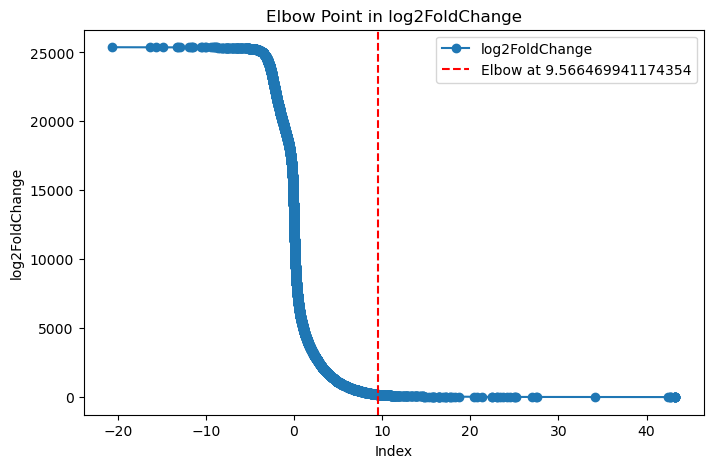

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ZNF622P1,6.264243e+04,-20.674450,4.253291,-4.860813,1.169049e-06,4.058566e-05
WFDC11,2.727486e+05,-16.291857,1.169068,-13.935766,3.840598e-44,1.082963e-40
PRSS37,1.643864e+04,-15.630219,1.018022,-15.353514,3.355094e-53,1.419093e-49
GLYATL1,1.495215e+05,-14.925023,1.220618,-12.227431,2.218433e-34,2.085163e-31
C1orf87,1.284620e+04,-13.293753,1.240866,-10.713285,8.817656e-27,5.238876e-24
...,...,...,...,...,...,...
TMEM187,1.132096e+06,25.179560,1.428888,17.621790,1.676167e-69,4.253776e-65
Unnamed: 33813,3.666245e+06,26.968565,1.746134,15.444726,8.187536e-54,4.155666e-50
GIMAP1-GIMAP5,1.205429e+07,27.410187,1.590552,17.233129,1.498241e-66,1.901118e-62
Unnamed: 32081,8.649072e+05,27.551826,2.055510,13.403890,5.737546e-41,1.040053e-37


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Example DataFrame
df = dds
value='log2FoldChange'
# Step 1: Sort by log2FoldChange (ascending or descending)
df = df.sort_values(by=value, ascending=False).reset_index(drop=True)

# Step 2: Normalize values (optional)
y = np.arange(len(df))  # Indices (gene positions)
x = df[value].values

# Step 3: Apply Kneedle algorithm to find the elbow point
kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')  # Direction depends on sorting
elbow_point = kneedle.elbow

# Plot the log2FoldChange with the detected elbow point
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=value, marker='o')
plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow at {elbow_point}')
plt.title(f'Elbow Point in {value}')
plt.xlabel('Index')
plt.ylabel(value)
plt.legend()
plt.show()

### get elbow point
elbow = elbow_point 
#elbow = 15
dds_de = dds[(abs(dds[value])>elbow) & (dds['padj']<0.1)]

dds_de.sort_values(by='log2FoldChange')

In [40]:
top_genes = dds_de[dds_de['padj'] < 0.05].index
print(len(top_genes))
top_genes= [item for item in top_genes if "Unnamed" not in item and "NAN" not in item]
len(top_genes)

191


160

In [41]:
# Infer enrichment with ora using significant deg

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,AAACCAC_MIR140,110,0.009091,0.587684,0.999991,1.692833,0.899852,TAF9B
1,AAAGACA_MIR511,204,0.014706,0.224049,0.999991,2.151209,3.217977,CAMK2N1;CCDC178;RAB22A
2,AAAGGAT_MIR501,127,0.007874,0.640602,0.999991,1.465868,0.652819,RAB22A
3,AAAGGGA_MIR204_MIR211,224,0.013393,0.266681,0.999991,1.957585,2.587341,EDEM1;PLAG1;SGCZ
4,AAANWWTGC_UNKNOWN,194,0.010309,0.461030,0.999991,1.606197,1.243668,ATOH7;SALL3


In [15]:
enr_pvals.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', header=True)

In [42]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.05) & (enr_pvals["FDR p-value"] < 0.05)]
significant_ORA

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


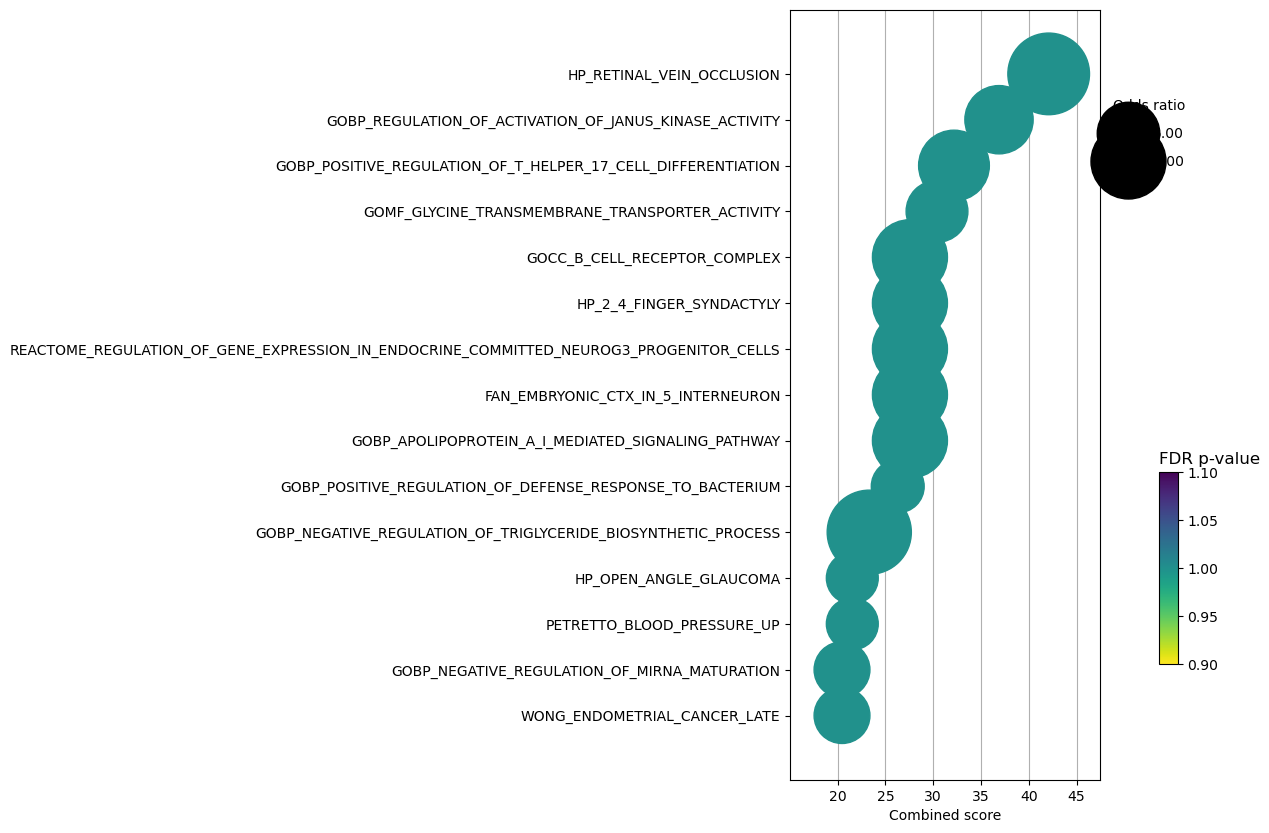

In [17]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=1.5,
    figsize=(5, 10)
)

### GSEA vs ORA

In [18]:
enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge


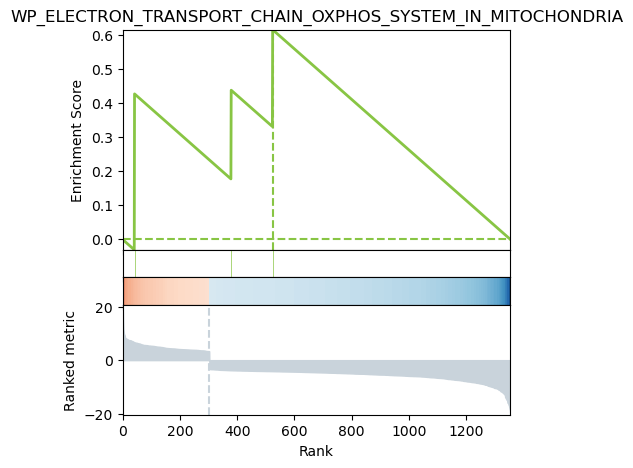

In [29]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

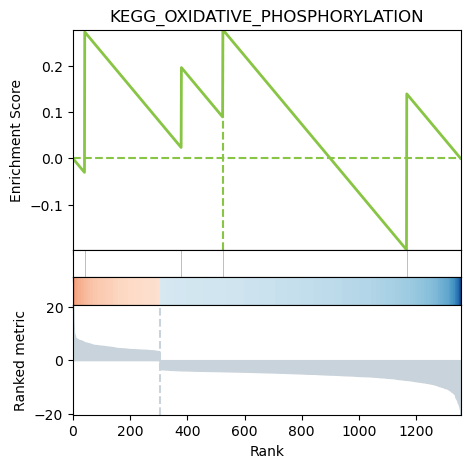

In [30]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

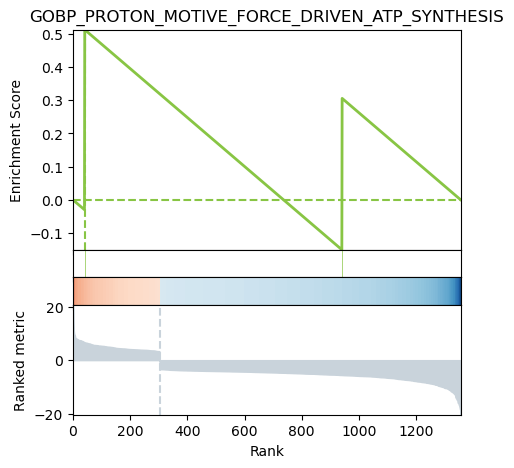

In [31]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

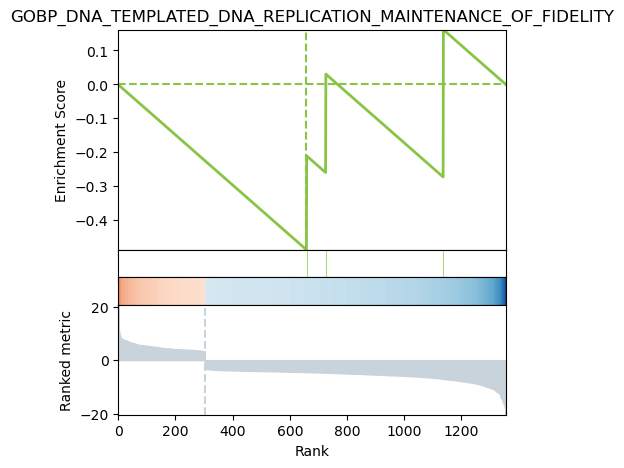

In [32]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



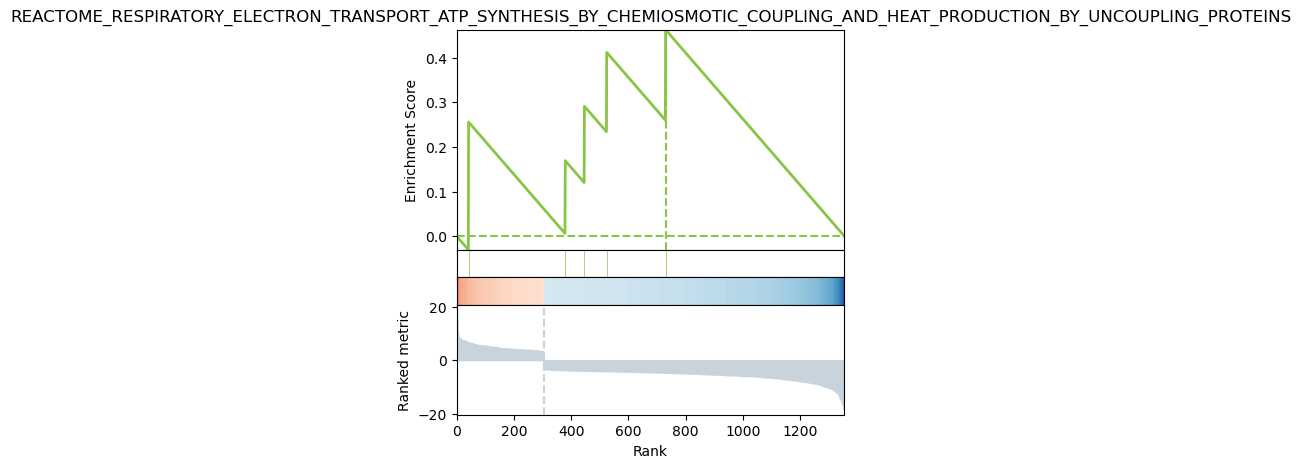

In [33]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [26]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}